In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Tuition Centre Student-Tutor Assignment Optimisation

This notebook formulates and solves an Integer Programming (IP) assignment problem for a tutoring organisation. Each month, new students must be assigned to tutors across multiple tuition centres.

### Problem Requirements
- Each student is assigned **exactly one tutor**
- Students requiring **extensive tutoring** can only be assigned to tutors with **extensive skill**
- The total number of students per tutor (existing active + newly assigned) cannot exceed their **maximum overall capacity**
- Tutors have indicated their **top 2 preferred centres**; assignments should maximise preference matching where possible

### Two Scenarios
**(a)** Minimise the number of tutors used, then maximise tutor centre preference  
**(b)** Balance tutor workload as evenly as possible, then maximise tutor centre preference

### Assumptions
- Only **active** existing students count towards a tutor's current load; inactive historical records are excluded
- **Preference scoring:** pref1 (first choice centre) = **2**, pref2 (second choice) = **1**, no match = **0**. This weighted scheme is applied to both scenarios as it better reflects the true strength of a preference match. Using equal weighting (1/1) would allow the model to freely substitute pref1 matches with pref2 matches, producing a weaker outcome in practice
- **Workload balancing (Scenario b):** tutors whose existing active load already meets or exceeds the computed mean are considered *saturated* and receive no new students. The mean is recomputed iteratively after excluding saturated tutors until stable. Balance is measured on **total load** (existing + new), not just new assignments

In [3]:
import math
import pandas as pd
from docplex.mp.model import Model

## 1. Data Loading & Pre-processing

Reads the three sheets from the Excel file, counts active existing students per tutor, checks feasibility, and builds eligibility and preference score lookups for each (student, tutor) pair.

In [5]:
def load_data(excel_path: str):
    new_students = pd.read_excel(excel_path, sheet_name="New Students")
    tutors       = pd.read_excel(excel_path, sheet_name="Tutor Information")
    existing     = pd.read_excel(excel_path, sheet_name="Existing Students")

    # Ensure consistent string formatting across all columns
    for df in (new_students, tutors, existing):
        for c in df.columns:
            if df[c].dtype == "object":
                df[c] = df[c].astype(str).str.strip()

    # Count only ACTIVE existing students towards capacity.
    # Cast to string to safely handle both boolean True and string "True" from Excel.
    existing_active = existing[
        existing["active"].astype(str).str.strip().str.lower() == "true"
    ].copy()
    exist_count = (
        existing_active.groupby("tutorId")["studentId"]
        .nunique()
        .to_dict()
    )

    S = new_students["studentId"].tolist()
    T = tutors["tutorId"].tolist()

    need   = dict(zip(new_students["studentId"], new_students["tutoringNeed"]))
    centre = dict(zip(new_students["studentId"], new_students["tuitionCentre"]))
    skill  = dict(zip(tutors["tutorId"], tutors["tutoringSkills"]))
    pref1  = dict(zip(tutors["tutorId"], tutors["preferredCentre1"]))
    pref2  = dict(zip(tutors["tutorId"], tutors["preferredCentre2"]))
    cap    = dict(zip(tutors["tutorId"], tutors["maxOverallCapacity"]))

    # Feasibility check: existing active load must not already exceed capacity
    for t in T:
        if exist_count.get(t, 0) > cap[t]:
            raise ValueError(
                f"Infeasible data: tutor {t} has existing_active={exist_count.get(t,0)} "
                f"> capacity={cap[t]}"
            )

    # Build eligibility and preference score lookups for each (student, tutor) pair
    # Scoring: pref1 match = 2, pref2 match = 1, no match = 0
    eligible = {}
    score    = {}
    for s in S:
        for t in T:
            is_eligible = (
                need[s] == "Normal" or
                (need[s] == "Extensive" and skill[t] == "Extensive")
            )
            eligible[(s, t)] = int(is_eligible)

            if centre[s] == pref1[t]:
                score[(s, t)] = 2
            elif centre[s] == pref2[t]:
                score[(s, t)] = 1
            else:
                score[(s, t)] = 0

    return {
        "S": S, "T": T,
        "need": need, "centre": centre,
        "skill": skill, "pref1": pref1, "pref2": pref2,
        "cap": cap, "exist_count": exist_count,
        "eligible": eligible, "score": score,
    }

excel_path = "Interview small data.xlsx"
params = load_data(excel_path)
print(f"Loaded {len(params['S'])} new students and {len(params['T'])} tutors.")

Loaded 20 new students and 10 tutors.


## 2. Common Model Builder

Shared across both scenarios. Builds the base IP model with:
- **x[s,t]** -- binary: 1 if student `s` is assigned to tutor `t`
- **y[t]** -- binary: 1 if tutor `t` receives at least one new student
- **(C1)** Each student assigned to exactly one tutor
- **(C2)** Existing active + new assigned <= tutor max capacity
- **(C3)** Linking constraint: y[t] = 1 iff tutor t receives any new students

In [7]:
def build_common_assignment_model(params, model_name="assignment", cap_override=None):
    """
    Builds the base IP assignment model shared by both scenarios.
    cap_override: optional dict {tutorId: effective_capacity} used in Scenario (b)
                  to block saturated tutors from receiving new students.
    """
    S, T        = params["S"], params["T"]
    cap         = cap_override if cap_override is not None else params["cap"]
    exist_count = params["exist_count"]
    eligible    = params["eligible"]
    score       = params["score"]

    M = len(S)  # big-M for linking constraints
    mdl = Model(name=model_name)

    # Only create x variables for eligible (student, tutor) pairs
    eligible_pairs = [(s, t) for s in S for t in T if eligible[(s, t)] == 1]
    x = mdl.binary_var_dict(eligible_pairs, name="x")  # x[s,t] in {0,1}
    y = mdl.binary_var_dict(T, name="y")               # y[t] in {0,1}

    # (C1) Each student assigned to exactly one tutor
    for s in S:
        mdl.add_constraint(
            mdl.sum(x[(s, t)] for t in T if (s, t) in x) == 1,
            ctname=f"assign_{s}"
        )

    # (C2) Capacity: existing active + new assigned <= max capacity
    for t in T:
        mdl.add_constraint(
            exist_count.get(t, 0) + mdl.sum(x[(s, t)] for s in S if (s, t) in x) <= cap[t],
            ctname=f"cap_{t}"
        )

    # (C3) Link y[t] to whether tutor t receives any new students
    for t in T:
        new_load_t = mdl.sum(x[(s, t)] for s in S if (s, t) in x)
        mdl.add_constraint(new_load_t <= M * y[t], ctname=f"link_up_{t}")
        mdl.add_constraint(new_load_t >= y[t],     ctname=f"link_low_{t}")

    # Preference expression: weighted sum of scores across all assignments
    pref_expr = mdl.sum(score[(s, t)] * x[(s, t)] for (s, t) in x)

    return mdl, x, y, pref_expr, M


def extract_solution(params, x_sol):
    """Return a DataFrame mapping each student to their assigned tutor."""
    S, T = params["S"], params["T"]
    rows = []
    for s in S:
        chosen_t = None
        for t in T:
            if (s, t) in x_sol and x_sol[(s, t)].solution_value > 0.5:
                chosen_t = t
                break
        rows.append({"studentId": s, "assignedTutor": chosen_t})
    return pd.DataFrame(rows)

## 3. Scenario (a) -- Minimise Tutors Used, then Maximise Preference

**Two-stage lexicographic approach:**
1. **Stage 1:** Minimise the number of tutors assigned (minimise sum of y[t])
2. **Stage 2:** Fix tutor count to the Stage 1 optimum K*, then maximise total preference score

This ensures the primary objective (fewest tutors) is never compromised when optimising the secondary objective (preference).

In [9]:
def solve_a(params, log_output=True):
    # Stage 1: minimise number of tutors used
    mdl1, x1, y1, _, M = build_common_assignment_model(params, model_name="A_stage1")
    tutors_used_expr1 = mdl1.sum(y1[t] for t in params["T"])
    mdl1.minimize(tutors_used_expr1)

    sol1 = mdl1.solve(log_output=log_output)
    if sol1 is None:
        raise RuntimeError("Scenario (a) Stage 1 infeasible or no solution.")

    K_star = int(round(sol1.get_value(tutors_used_expr1)))
    print(f"Stage 1 complete -- minimum tutors required: {K_star}")

    # Stage 2: fix tutor count to K_star, maximise preference score
    mdl2, x2, y2, pref2, M = build_common_assignment_model(params, model_name="A_stage2")
    tutors_used_expr2 = mdl2.sum(y2[t] for t in params["T"])
    mdl2.add_constraint(tutors_used_expr2 == K_star, ctname="fix_num_tutors")
    mdl2.maximize(pref2)

    sol2 = mdl2.solve(log_output=log_output)
    if sol2 is None:
        raise RuntimeError("Scenario (a) Stage 2 infeasible or no solution.")

    assign_df = extract_solution(params, x2)
    return K_star, sol2.objective_value, assign_df


K_star, pref_score_a, assign_a = solve_a(params, log_output=False)
print(f"\n=== Scenario (a) Results ===")
print(f"Tutors used      : {K_star}")
print(f"Preference score : {pref_score_a}")
display(assign_a)

-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0
Stage 1 complete -- minimum tutors required: 4
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0

=== Scenario (a) Results ===
Tutors used      : 4
Preference score : 39.0


,studentId,assignedTutor
0,S0001,A001
1,S0002,A010
2,S0003,A009
3,S0004,A001
4,S0005,A009
5,S0006,A001
6,S0007,A001
7,S0008,A009
8,S0009,A002
9,S0010,A010


## 4. Scenario (b) -- Balance Workload, then Maximise Preference

### Step 1: Pre-processing -- Computing the Target Mean Load

Before optimising, we identify *saturated* tutors whose existing active load already meets or exceeds the mean. Assigning new students to them would only worsen the balance.

**Algorithm:**
1. Compute mean = (total existing active + total new students) / number of tutors
2. Identify tutors whose existing load >= mean -- mark as saturated
3. Remove saturated tutors and recompute mean with remaining tutors
4. Repeat until no new saturated tutors are found

In [11]:
def compute_mean_target(params):
    """
    Iteratively compute the converged target mean workload.
    Returns the mean, its ceiling, active tutors, saturated tutors,
    and effective capacities to pass to the optimisation model.
    """
    T           = params["T"]
    S           = params["S"]
    exist_count = params["exist_count"]
    cap         = params["cap"]

    total_new        = len(S)
    remaining_tutors = list(T)
    saturated        = []

    while True:
        total_existing = sum(exist_count.get(t, 0) for t in remaining_tutors)
        mean = (total_existing + total_new) / len(remaining_tutors)

        newly_saturated = [t for t in remaining_tutors if exist_count.get(t, 0) >= mean]

        if not newly_saturated:
            break

        saturated.extend(newly_saturated)
        remaining_tutors = [t for t in remaining_tutors if t not in newly_saturated]

        if not remaining_tutors:
            raise RuntimeError(
                "All tutors are already at or above the computed mean. "
                "No tutor can accept new students."
            )

    for t in remaining_tutors:
        if cap[t] - exist_count.get(t, 0) <= 0:
            raise RuntimeError(f"Tutor {t} has no remaining capacity despite being below mean.")

    mean_ceil = math.ceil(mean)

    # Saturated tutors: cap = existing load (blocks any new assignment)
    # Active tutors: retain real cap; balance enforced via the objective
    effective_cap = {
        t: (exist_count.get(t, 0) if t in saturated else cap[t])
        for t in T
    }

    print(f"[Workload Balance Pre-processing]")
    print(f"  Total new students : {total_new}")
    print(f"  Saturated tutors   : {saturated} (existing load >= mean, receive no new students)")
    print(f"  Active tutors      : {remaining_tutors}")
    print(f"  Converged mean     : {mean:.2f}  (ceiling = {mean_ceil})")

    return mean, mean_ceil, remaining_tutors, saturated, effective_cap

### Step 2: Optimisation -- Minimise Max Load, then Maximise Preference

**Two-stage lexicographic approach:**
1. **Stage 1:** Among active tutors, minimise the maximum total load (existing + new). This pushes all active tutors toward the mean, with any remainder spread naturally by the min-max objective
2. **Stage 2:** Fix the optimal max load from Stage 1, then maximise the preference score. Weighted (2/1) scoring is used here to also keep tutors near their preferred centre -- cross-district assignments undermine the spirit of a balanced workload

In [13]:
def solve_b(params, log_output=True):
    S, T        = params["S"], params["T"]
    exist_count = params["exist_count"]

    mean, mean_ceil, active_tutors, saturated_tutors, effective_cap = compute_mean_target(params)

    params_b        = dict(params)
    params_b["cap"] = effective_cap

    # Stage 1: minimise max TOTAL load (existing + new) among active tutors
    mdl1, x1, y1, _, M = build_common_assignment_model(
        params_b, model_name="B_stage1", cap_override=effective_cap
    )
    Lmax1 = mdl1.integer_var(lb=0, name="Lmax")

    for t in active_tutors:
        total_load_t = exist_count.get(t, 0) + mdl1.sum(x1[(s, t)] for s in S if (s, t) in x1)
        mdl1.add_constraint(total_load_t <= Lmax1, ctname=f"def_Lmax_{t}")

    for t in saturated_tutors:
        mdl1.add_constraint(
            mdl1.sum(x1[(s, t)] for s in S if (s, t) in x1) == 0,
            ctname=f"saturated_{t}"
        )

    mdl1.minimize(Lmax1)
    sol1 = mdl1.solve(log_output=log_output)
    if sol1 is None:
        raise RuntimeError("Scenario (b) Stage 1 infeasible or no solution.")

    Lmax_star = int(round(sol1.objective_value))
    print(f"Stage 1 complete -- optimal max total load: {Lmax_star}  (target mean: {mean:.2f})")

    # Stage 2: fix Lmax, maximise preference score
    mdl2, x2, y2, pref_expr2, M = build_common_assignment_model(
        params_b, model_name="B_stage2", cap_override=effective_cap
    )
    Lmax2 = mdl2.integer_var(lb=0, name="Lmax")

    for t in active_tutors:
        total_load_t = exist_count.get(t, 0) + mdl2.sum(x2[(s, t)] for s in S if (s, t) in x2)
        mdl2.add_constraint(total_load_t <= Lmax2, ctname=f"def_Lmax_{t}")

    for t in saturated_tutors:
        mdl2.add_constraint(
            mdl2.sum(x2[(s, t)] for s in S if (s, t) in x2) == 0,
            ctname=f"saturated_{t}"
        )

    mdl2.add_constraint(Lmax2 == Lmax_star, ctname="fix_max_load")
    mdl2.maximize(pref_expr2)

    sol2 = mdl2.solve(log_output=log_output)
    if sol2 is None:
        raise RuntimeError("Scenario (b) Stage 2 infeasible or no solution.")

    assign_df = extract_solution(params_b, x2)
    return Lmax_star, mean, sol2.objective_value, assign_df


Lmax_star, mean_target, pref_score_b, assign_b = solve_b(params, log_output=False)
print(f"\n=== Scenario (b) Results ===")
print(f"Target mean total load          : {round(mean_target, 2)}")
print(f"Optimal max total load (active) : {Lmax_star}")
print(f"Preference score                : {pref_score_b}")
display(assign_b)

[Workload Balance Pre-processing]
  Total new students : 20
  Saturated tutors   : ['A005', 'A007'] (existing load >= mean, receive no new students)
  Active tutors      : ['A001', 'A002', 'A003', 'A004', 'A006', 'A008', 'A009', 'A010']
  Converged mean     : 2.88  (ceiling = 3)
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0
Stage 1 complete -- optimal max total load: 3  (target mean: 2.88)
-- cannot find parameters matching version: 22.1.2.0, using: 22.1.1.0

=== Scenario (b) Results ===
Target mean total load          : 2.88
Optimal max total load (active) : 3
Preference score                : 35.0


,studentId,assignedTutor
0,S0001,A001
1,S0002,A003
2,S0003,A009
3,S0004,A006
4,S0005,A009
5,S0006,A001
6,S0007,A006
7,S0008,A008
8,S0009,A004
9,S0010,A008


## 5. Export Results to Excel

In [15]:
output_path = "Assignment Results.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    assign_a.to_excel(writer, sheet_name="Scenario A", index=False)
    assign_b.to_excel(writer, sheet_name="Scenario B", index=False)

print(f"Results exported to '{output_path}' with sheets: 'Scenario A', 'Scenario B'")

Results exported to 'Assignment Results.xlsx' with sheets: 'Scenario A', 'Scenario B'


## 6. Visualisations

Three charts summarising the optimisation results:
- **Tutor Workload** — existing vs. newly assigned students per tutor, with capacity limits
- **Preference Match Breakdown** — how many students received a first-choice, second-choice, or no match
- **Assignment Heatmap** — student × tutor assignment matrix for each scenario

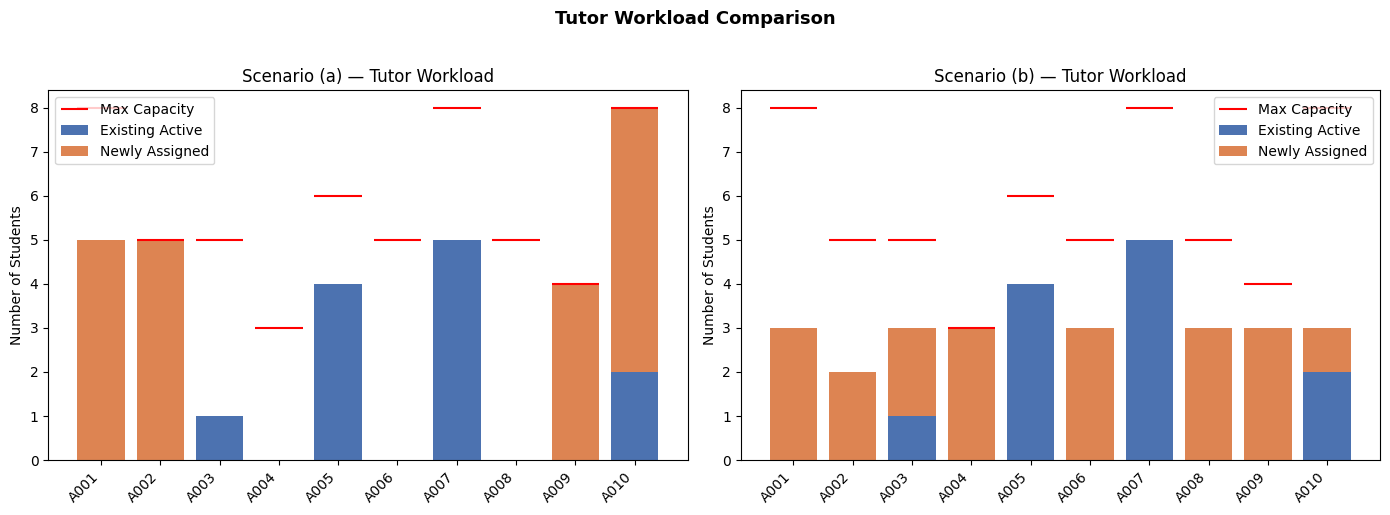

Saved: workload_comparison.png


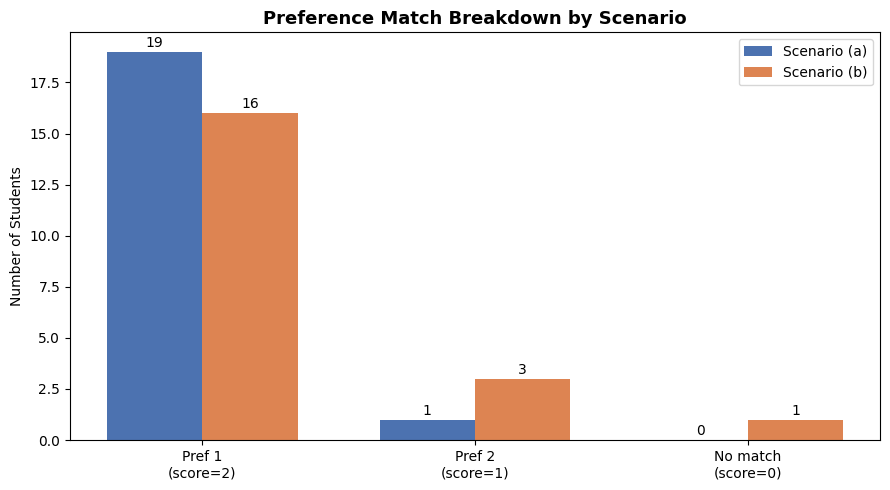

Saved: preference_breakdown.png


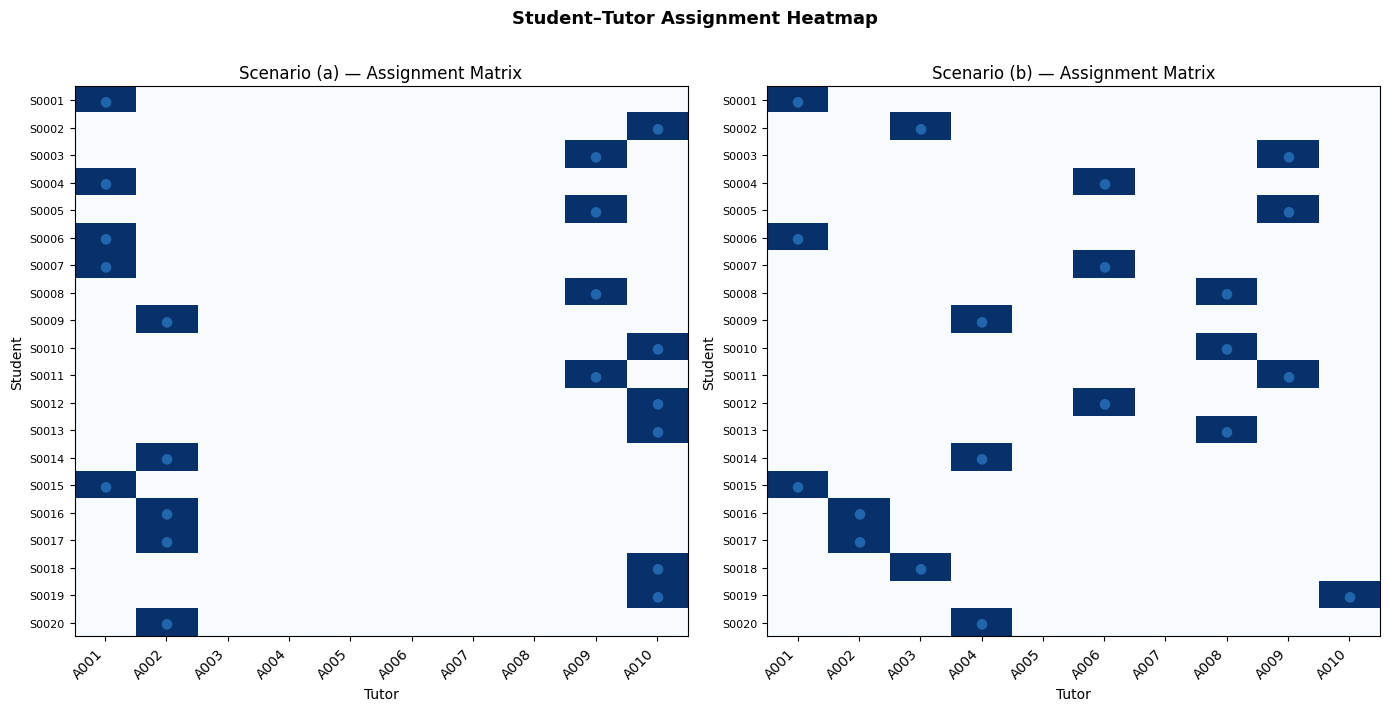

Saved: assignment_heatmap.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


# ── 1. Tutor Workload Comparison ──────────────────────────────────────────────
def plot_workload(params, assign_a, assign_b):
    T = params["T"]
    exist_count = params["exist_count"]
    cap = params["cap"]

    new_a = assign_a.groupby("assignedTutor").size().reindex(T, fill_value=0)
    new_b = assign_b.groupby("assignedTutor").size().reindex(T, fill_value=0)
    existing = pd.Series({t: exist_count.get(t, 0) for t in T})
    capacity = pd.Series({t: cap[t] for t in T})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, new_assign, title in zip(axes, [new_a, new_b], ["Scenario (a)", "Scenario (b)"]):
        x = list(range(len(T)))
        ax.bar(x, existing[T], label="Existing Active", color="#4C72B0")
        ax.bar(x, new_assign[T], bottom=existing[T], label="Newly Assigned", color="#DD8452")
        # Draw capacity as a step line
        cap_vals = [capacity[t] for t in T]
        for i, (xi, cv) in enumerate(zip(x, cap_vals)):
            ax.hlines(cv, xi - 0.4, xi + 0.4, colors="red", linewidths=1.5,
                      label="Max Capacity" if i == 0 else "")
        ax.set_xticks(x)
        ax.set_xticklabels(T, rotation=45, ha="right")
        ax.set_ylabel("Number of Students")
        ax.set_title(title + " — Tutor Workload")
        ax.legend()

    plt.suptitle("Tutor Workload Comparison", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("workload_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: workload_comparison.png")


# ── 2. Preference Score Breakdown ─────────────────────────────────────────────
def plot_preference_breakdown(params, assign_a, assign_b):
    score = params["score"]

    def get_pref_counts(assign_df):
        counts = {"Pref 1\n(score=2)": 0, "Pref 2\n(score=1)": 0, "No match\n(score=0)": 0}
        for _, row in assign_df.iterrows():
            s, t = row["studentId"], row["assignedTutor"]
            v = score.get((s, t), 0)
            if v == 2:   counts["Pref 1\n(score=2)"] += 1
            elif v == 1: counts["Pref 2\n(score=1)"] += 1
            else:        counts["No match\n(score=0)"] += 1
        return counts

    counts_a = get_pref_counts(assign_a)
    counts_b = get_pref_counts(assign_b)

    labels = list(counts_a.keys())
    vals_a = [counts_a[l] for l in labels]
    vals_b = [counts_b[l] for l in labels]

    x = list(range(len(labels)))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_a = ax.bar([i - width/2 for i in x], vals_a, width, label="Scenario (a)", color="#4C72B0")
    bars_b = ax.bar([i + width/2 for i in x], vals_b, width, label="Scenario (b)", color="#DD8452")

    # Add value labels on bars
    for bar in list(bars_a) + list(bars_b):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)),
                ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Number of Students")
    ax.set_title("Preference Match Breakdown by Scenario", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("preference_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: preference_breakdown.png")


# ── 3. Assignment Heatmap ──────────────────────────────────────────────────────
def plot_assignment_heatmap(params, assign_a, assign_b):
    S, T = params["S"], params["T"]

    def to_matrix(assign_df):
        mat = pd.DataFrame(0, index=S, columns=T)
        for _, row in assign_df.iterrows():
            mat.loc[row["studentId"], row["assignedTutor"]] = 1
        return mat

    mat_a = to_matrix(assign_a)
    mat_b = to_matrix(assign_b)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, mat, title in zip(axes, [mat_a, mat_b], ["Scenario (a)", "Scenario (b)"]):
        ax.imshow(mat.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(T)))
        ax.set_xticklabels(T, rotation=45, ha="right")
        ax.set_yticks(range(len(S)))
        ax.set_yticklabels(S, fontsize=8)
        ax.set_title(title + " — Assignment Matrix", fontsize=12)
        ax.set_xlabel("Tutor")
        ax.set_ylabel("Student")
        # Mark assigned cells with a dot
        for si, s in enumerate(S):
            for ti, t in enumerate(T):
                if mat.loc[s, t] == 1:
                    ax.text(ti, si, "●", ha="center", va="center",
                            color="#2166ac", fontsize=10)

    plt.suptitle("Student–Tutor Assignment Heatmap", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("assignment_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: assignment_heatmap.png")


# ── Run all three ──────────────────────────────────────────────────────────────
plot_workload(params, assign_a, assign_b)
plot_preference_breakdown(params, assign_a, assign_b)
plot_assignment_heatmap(params, assign_a, assign_b)
